In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingRegressor as gb

from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             mean_squared_error, r2_score)
from sklearn.preprocessing import StandardScaler

avocados = pd.read_csv('../docs/clean_avocado.csv')
avocados.head()



,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,...,region_SOUTHCAROLINA,region_SOUTHCENTRAL,region_SOUTHEAST,region_SPOKANE,region_STLOUIS,region_SYRACUSE,region_TAMPA,region_TOTALUS,region_WEST,region_WESTTEXNEWMEXICO
0,2015-12-27,-0.162848,-0.115021,-0.616377,0.369351,-0.286600,-0.504590,-0.260728,-0.671562,-0.646579,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2015-12-20,-0.110121,-0.183584,-0.744123,0.299899,-0.241293,-0.465177,-0.225881,-0.660104,-0.646579,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2015-12-13,-1.217387,0.150551,-0.695336,0.612314,-0.049524,-0.533632,-0.287034,-0.645580,-0.646579,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2015-12-06,-0.821935,-0.024995,-0.590266,0.466825,-0.189427,-0.683308,-0.422779,-0.578466,-0.646579,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2015-11-29,-0.294666,-0.215146,-0.645003,0.293577,-0.179170,-0.655747,-0.402128,-0.477375,-0.646579,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [35]:
avocados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17934 entries, 0 to 17933
Data columns (total 65 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        17934 non-null  object 
 1   AveragePrice                17934 non-null  float64
 2   Total Volume                17934 non-null  float64
 3   4046                        17934 non-null  float64
 4   4225                        17934 non-null  float64
 5   4770                        17934 non-null  float64
 6   Total Bags                  17934 non-null  float64
 7   Small Bags                  17934 non-null  float64
 8   Large Bags                  17934 non-null  float64
 9   XLarge Bags                 17934 non-null  float64
 10  year                        17934 non-null  int64  
 11  type_ORGANIC                17934 non-null  float64
 12  region_ATLANTA              17934 non-null  float64
 13  region_BALTIMOREWASHINGTON  179

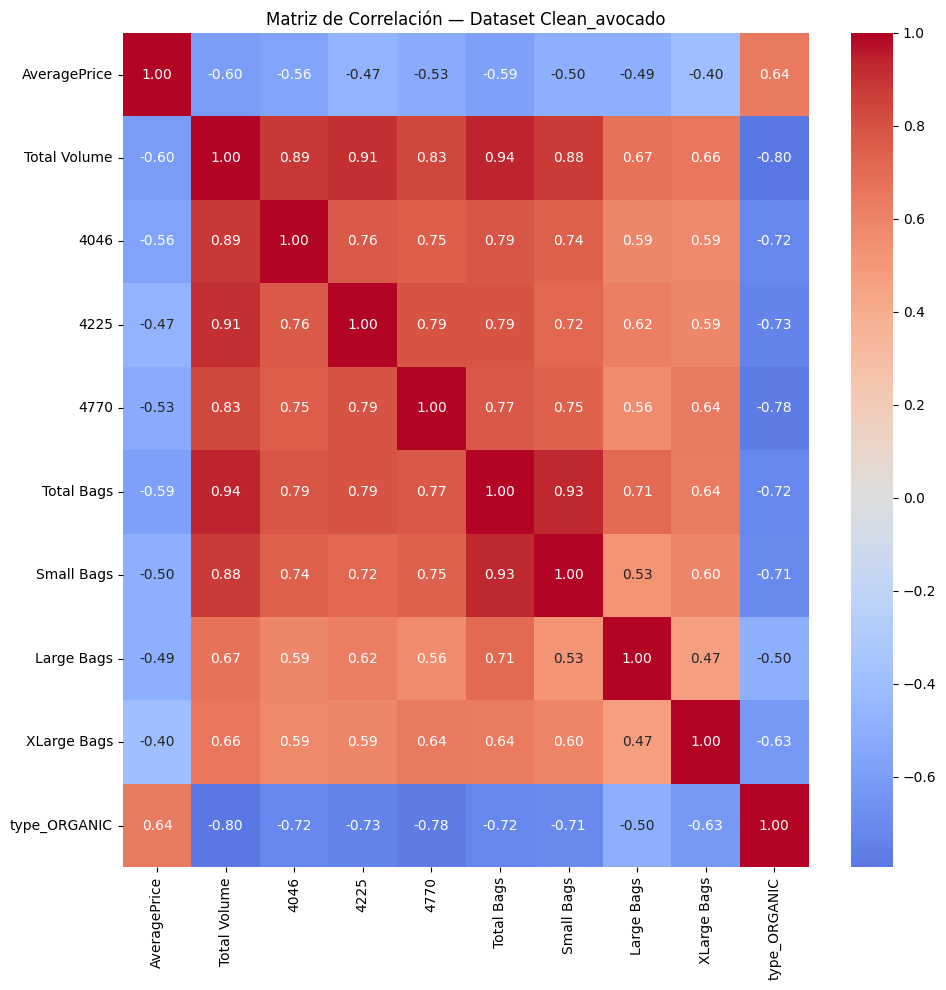

In [36]:
plt.figure(figsize=(10, 10))
numeric_cols = ['AveragePrice','Total Volume', '4046', '4225', '4770',
                'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type_ORGANIC']
sns.heatmap(avocados[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlación — Dataset Clean_avocado')
plt.tight_layout()
plt.show()

### 1. importar datos y generar conjuntos de entrenamiento y testing

se debe aplicar una transformacion ya que se pede ver que una de las columnas es de tipo object, convertimos la fecha en datetime para poder trabajar con este dato

In [37]:
#avocados.describe()

avocados["Date"] = pd.to_datetime(avocados["Date"])
avocados["Month"] = avocados["Date"].dt.month
# Variables predictoras (X) y objetivo (y)
X = avocados.drop(columns=['AveragePrice', "Date"])
y = avocados['AveragePrice']  
feature_names = X.columns

# Dividir datos en entrenamiento y prueba (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

avocados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17934 entries, 0 to 17933
Data columns (total 66 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Date                        17934 non-null  datetime64[ns]
 1   AveragePrice                17934 non-null  float64       
 2   Total Volume                17934 non-null  float64       
 3   4046                        17934 non-null  float64       
 4   4225                        17934 non-null  float64       
 5   4770                        17934 non-null  float64       
 6   Total Bags                  17934 non-null  float64       
 7   Small Bags                  17934 non-null  float64       
 8   Large Bags                  17934 non-null  float64       
 9   XLarge Bags                 17934 non-null  float64       
 10  year                        17934 non-null  int64         
 11  type_ORGANIC                17934 non-null  float64   

### 2. Entrenamiento del modelo


In [39]:
GB = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
GB.fit(X_train, y_train)



,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


### 3. Resultado

In [42]:
y_pred = GB.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")    

Mean Squared Error: 0.2667
R² Score: 0.7387
